In [1]:
import os
import sys
import pandas as pd

# ========= USER CONFIG =========
FRED_API_KEY = "cf3ed89ca1a5a31333debb5662876c9e"

# FRED series
SERIES = {
    "PCE": "PCEPI",          # Personal Consumption Expenditures Price Index
    "CPI-Core": "CPILFESL",  # CPI less food & energy
    "Real Broad Dollar": "RTWEXBGS"
}

# --- One filter controls BOTH figures ---
FILTER_MODE = "range"   # "months" or "range"
NUM_MONTHS  = 36        # used when FILTER_MODE == "months"
START = "2015-01-01"    # used when FILTER_MODE == "range"
END   = "2025-08-25"    # used when FILTER_MODE == "range"

# Plot/save paths
PARETO_MODULE_PATH = "/Users/paretoadvisoryllc/Desktop/Pareto/Plot_Style_Configuration"
SAVE_PATH_DOLLAR   = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/National/Figures/Real BroadDollar Index.jpg"
SAVE_PATH_DUALAXIS = "/Users/paretoadvisoryllc/Desktop/Pareto/Analysis/National/Figures/Inflation vs Dollar MA3.jpg"

TITLE_DOLLAR   = "Real Broad Dollar Index"
TITLE_DUALAXIS = "Inflation vs Dollar Strength — Dollar (3M MA, Inverted)"
SOURCE_LINE    = "Sources: FRED\nAnalysis by Nissi Cantu"

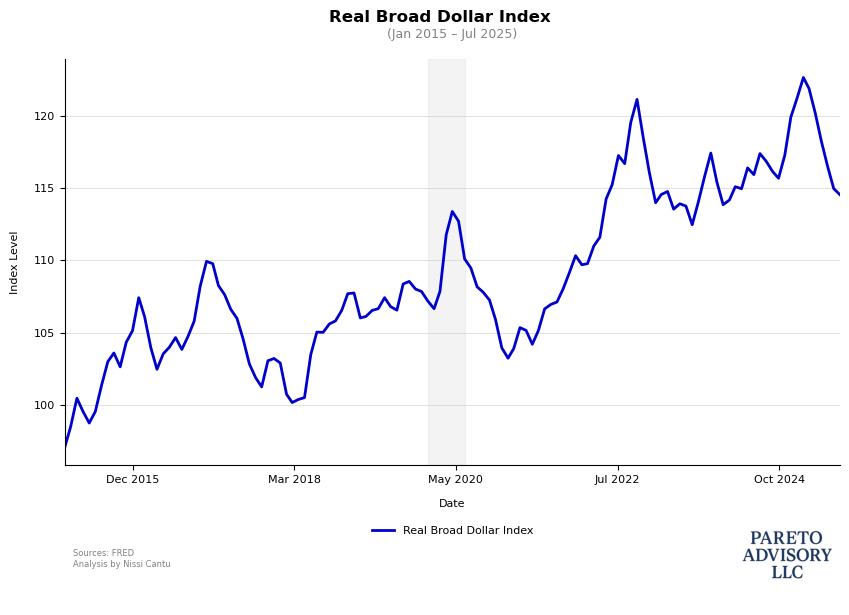

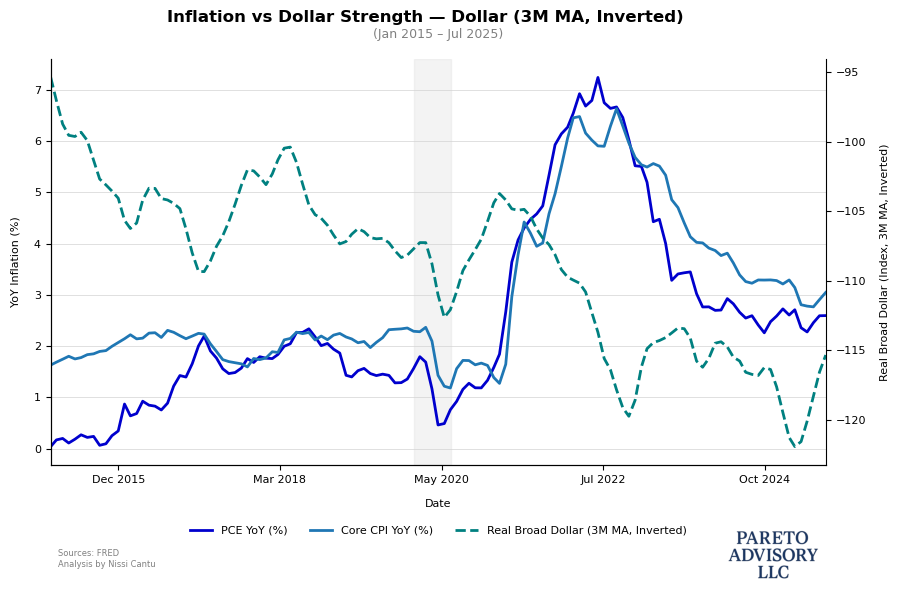

In [2]:
# ==============================

# House plotting
if PARETO_MODULE_PATH not in sys.path:
    sys.path.append(PARETO_MODULE_PATH)
from pareto_linechart import pareto_linechart, pareto_dualaxis_linechart


# ---------- Helpers ----------
def fetch_fred(series_id, api_key=None):
    """Fetch FRED series by ID (fredapi, fallback to pandas_datareader)."""
    try:
        from fredapi import Fred
        fred = Fred(api_key=api_key)
        s = fred.get_series(series_id); s.name = series_id
        return s
    except Exception:
        from pandas_datareader import data as pdr
        s = pdr.DataReader(series_id, "fred").iloc[:, 0]; s.name = series_id
        return s

def to_monthly(s: pd.Series) -> pd.Series:
    """Resample to month-end frequency (ME)."""
    s = s.sort_index()
    if not isinstance(s.index, pd.DatetimeIndex):
        s.index = pd.to_datetime(s.index)
    return s.resample("ME").last()

def yoy_pct(s: pd.Series) -> pd.Series:
    """Year-over-year % change."""
    return (s / s.shift(12) - 1.0) * 100.0

def ma_n(s: pd.Series, n: int) -> pd.Series:
    """Simple moving average with min_periods=1."""
    return s.rolling(window=n, min_periods=1).mean()

def apply_filter_window(df: pd.Series | pd.DataFrame,
                        mode: str,
                        num_months: int | None = None,
                        start: str | None = None,
                        end: str | None = None):
    """Apply recent-N-months or fixed START–END filter."""
    df = df.sort_index()
    if not isinstance(df.index, pd.DatetimeIndex):
        df.index = pd.to_datetime(df.index)

    m = mode.lower()
    if m == "months":
        if not num_months or num_months <= 0:
            raise ValueError("NUM_MONTHS must be positive when FILTER_MODE='months'.")
        cutoff = df.index[-1] - pd.DateOffset(months=int(num_months))
        return df[df.index > cutoff]
    elif m == "range":
        if start is not None:
            df = df[df.index >= pd.to_datetime(start)]
        if end is not None:
            df = df[df.index <= pd.to_datetime(end)]
        return df
    else:
        raise ValueError("FILTER_MODE must be 'months' or 'range'.")


def main():
    # --- Download raw series ---
    pce_raw  = fetch_fred(SERIES["PCE"], FRED_API_KEY)
    core_raw = fetch_fred(SERIES["CPI-Core"], FRED_API_KEY)
    rbd_raw  = fetch_fred(SERIES["Real Broad Dollar"], FRED_API_KEY)

    # --- Monthly frequency ---
    pce_m  = to_monthly(pce_raw)
    core_m = to_monthly(core_raw)
    rbd_m  = to_monthly(rbd_raw)

    # ================= FIGURE 1: Dollar (RAW level, no MA) =================
    rbd_filtered = apply_filter_window(rbd_m, FILTER_MODE, NUM_MONTHS, START, END)
    pareto_linechart(
        df=rbd_filtered.to_frame(name="Real Broad Dollar Index"),
        title_prefix=TITLE_DOLLAR,
        ylabel="Index Level",
        source_text=SOURCE_LINE,
        save_path=SAVE_PATH_DOLLAR
    )

    # ========== FIGURE 2: Inflation (raw YoY) vs Inverted Dollar (3M MA) ==========
    # Inflation: raw YoY (no MA)
    pce_yoy_raw  = yoy_pct(pce_m).rename("PCE YoY (%)")
    core_yoy_raw = yoy_pct(core_m).rename("Core CPI YoY (%)")

    # Dollar: 3M MA (for dual-axis only), inverted for intuitive relationship
    rbd_ma3 = ma_n(rbd_m, 3)

    # Apply the SAME filter to each series
    pce_f  = apply_filter_window(pce_yoy_raw, FILTER_MODE, NUM_MONTHS, START, END)
    core_f = apply_filter_window(core_yoy_raw, FILTER_MODE, NUM_MONTHS, START, END)
    rbd_f  = apply_filter_window(rbd_ma3,     FILTER_MODE, NUM_MONTHS, START, END)

    # Align overlapping period
    common_start = max(pce_f.index.min(), core_f.index.min(), rbd_f.index.min())
    common_end   = min(pce_f.index.max(), core_f.index.max(), rbd_f.index.max())
    pce_f  = pce_f[(pce_f.index  >= common_start) & (pce_f.index  <= common_end)]
    core_f = core_f[(core_f.index >= common_start) & (core_f.index <= common_end)]
    rbd_f  = rbd_f[(rbd_f.index  >= common_start) & (rbd_f.index  <= common_end)]

    # Build plotting frames
    left_df  = pd.concat([pce_f, core_f], axis=1).dropna(how="any")
    right_df = (-1.0 * rbd_f).rename("Real Broad Dollar (3M MA, Inverted)").to_frame()

    # Plot dual axis
    pareto_dualaxis_linechart(
        left_df=left_df,
        right_df=right_df,
        title_prefix=TITLE_DUALAXIS,
        left_ylabel="YoY Inflation (%)",
        right_ylabel="Real Broad Dollar (Index, 3M MA, Inverted)",
        source_text=SOURCE_LINE,
        save_path=SAVE_PATH_DUALAXIS,
        left_color="mediumblue",
        right_color="teal",
    )


if __name__ == "__main__":
    main()

In [3]:
# Note: The dollar has moved in super-cycles — 1980s (Volcker’s high rates),
# 1990s (tech boom), 2010s (QE weakness), 2022 (Fed hikes).
# Reflects how policy and global capital flows drive long swings.